In [12]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from datasets import load_dataset
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report

In [13]:
dataset = load_dataset("rajnandinib/CIFAR10")

train_data = dataset["train"]
test_data = dataset["test"]

print("Training images:", len(train_data))
print("Testing images:", len(test_data))

# CIFAR-10 class names
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

README.md:   0%|          | 0.00/1.71k [00:00<?, ?B/s]

C:\Users\dell\AppData\Local\Programs\Python\Python314\Lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\dell\.cache\huggingface\hub\datasets--rajnandinib--CIFAR10. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
C:\Users\dell\AppData\Local\Programs\Python\Python314\Lib\site-packages\huggingface_hub\file_d

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  120MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 23.9MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Training images: 50000
Testing images: 10000


In [15]:
x_train = np.array([
    np.array(image.convert("RGB"))
    for image in train_data["image"]
])

y_train = np.array(train_data["label"])

x_test = np.array([
    np.array(image.convert("RGB"))
    for image in test_data["image"]
])

y_test = np.array(test_data["label"])

print("Training shape:", x_train.shape)
print("Testing shape:", x_test.shape)

Training shape: (50000, 32, 32, 3)
Testing shape: (10000, 32, 32, 3)


In [16]:
#Normalize image pixels
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [20]:
# Build CNN Model
model = models.Sequential([

    # Convolution Layer 1
    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(32, 32, 3)
    ),

    layers.MaxPooling2D((2, 2)),

    # Convolution Layer 2
    layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D((2, 2)),

    # Convolution Layer 3
    layers.Conv2D(
        128,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D((2, 2)),

    # Convert feature maps to 1D
    layers.Flatten(),

    # Fully connected layer
    layers.Dense(128, activation="relu"),

    layers.Dropout(0.5),

    # Output layer
    layers.Dense(10, activation="softmax")
])

In [21]:
 #Compile Model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [22]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)


Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 33ms/step - accuracy: 0.3433 - loss: 1.7738 - val_accuracy: 0.4844 - val_loss: 1.4418
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.4934 - loss: 1.4058 - val_accuracy: 0.5554 - val_loss: 1.2411
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.5569 - loss: 1.2547 - val_accuracy: 0.6009 - val_loss: 1.1272
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.5948 - loss: 1.1519 - val_accuracy: 0.6224 - val_loss: 1.0747
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.6294 - loss: 1.0627 - val_accuracy: 0.6484 - val_loss: 1.0048
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - accuracy: 0.6557 - loss: 0.9915 - val_accuracy: 0.6685 - val_loss: 0.9482
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.6775 - loss: 0.9352 - val_accuracy: 0.6792 - val_loss: 0.9140
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.6966 - loss: 0.8785 - 

In [24]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test
)
print("\nTest Accuracy:", test_accuracy)


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6861 - loss: 0.9208

Test Accuracy: 0.6861000061035156


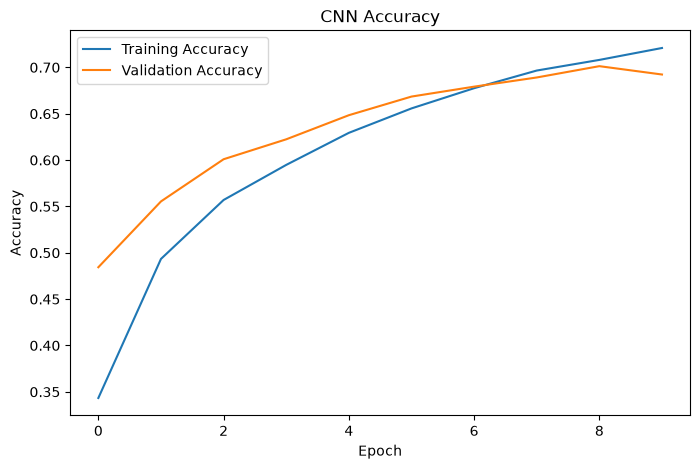

In [25]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy")
plt.legend()
plt.show()

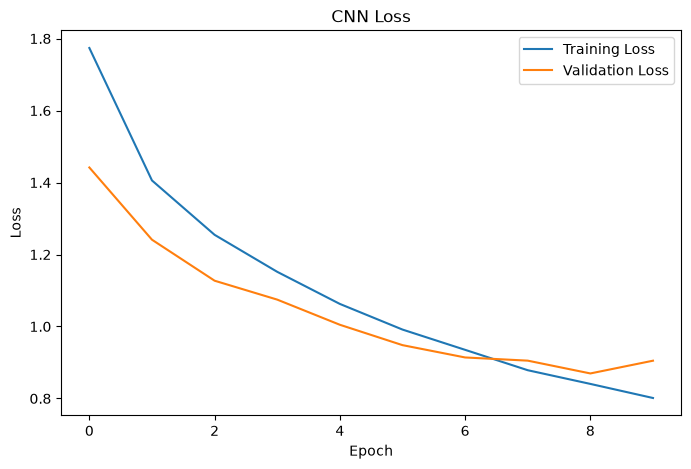

In [26]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss")
plt.legend()
plt.show()

In [27]:
predictions = model.predict(x_test)

predicted_classes = np.argmax(
    predictions,
    axis=1
)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


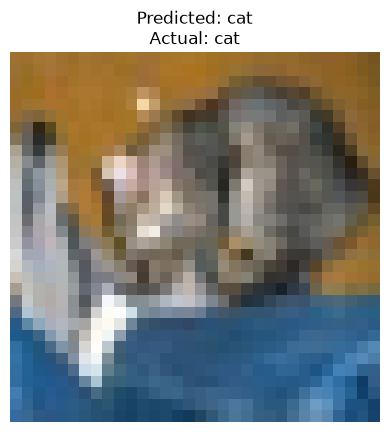

In [28]:
index = 0

plt.imshow(x_test[index])

plt.title(
    "Predicted: "
    + class_names[predicted_classes[index]]
    + "\nActual: "
    + class_names[y_test[index]]
)

plt.axis("off")
plt.show()


Classification Report:

              precision    recall  f1-score   support

    airplane       0.76      0.69      0.72      1000
  automobile       0.90      0.74      0.81      1000
        bird       0.64      0.50      0.56      1000
         cat       0.52      0.51      0.51      1000
        deer       0.62      0.62      0.62      1000
         dog       0.56      0.65      0.60      1000
        frog       0.81      0.72      0.76      1000
       horse       0.73      0.70      0.72      1000
        ship       0.75      0.84      0.79      1000
       truck       0.65      0.88      0.75      1000

    accuracy                           0.69     10000
   macro avg       0.69      0.69      0.69     10000
weighted avg       0.69      0.69      0.69     10000



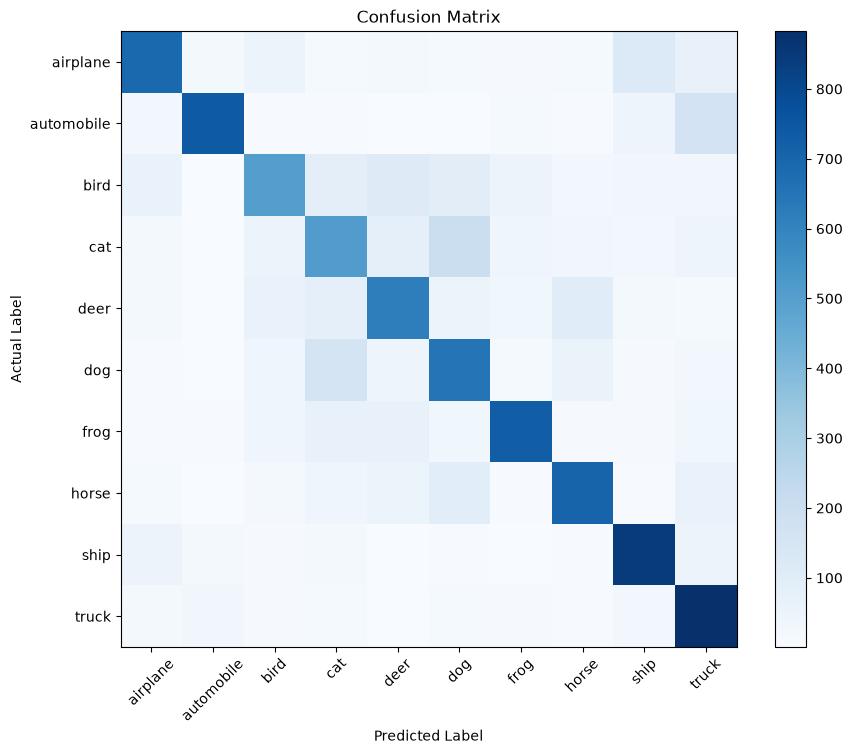

In [29]:
print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        predicted_classes,
        target_names=class_names
    )
)

# --------------------------------------------------
# 14. Confusion Matrix
# --------------------------------------------------

cm = confusion_matrix(
    y_test,
    predicted_classes
)

plt.figure(figsize=(10, 8))

plt.imshow(cm, cmap="Blues")

plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks(
    range(10),
    class_names,
    rotation=45
)

plt.yticks(
    range(10),
    class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()